# Sinusoid Bayesian-Torch: 5-Seed Evaluation

Fits the 4 Bayesian-Torch variants below (Flipout/BBB x scratch/MOPED) on the sinusoid regression task over 5 random seeds. Checkpoints use `sinusoid_bayesian_5seed/` and figures use the `5seed_sinusoid_` prefix.

In [1]:
from pathlib import Path
import sys, os, time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.stats import norm as _norm
from bayesian_torch.models.dnn_to_bnn import get_kl_loss

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "shared").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from shared import (checkpoint_exists, load_checkpoint, save_checkpoint,
                    seed_everything, regression_metrics, load_sinusoid,
                    combine_predictive_std, bt_mc_forward, optimize_noise_std_bt,
                    get_sinusoid_mlp, bt_predict, build_sinusoid_bt,
                    aggregate_seed_metrics, regression_calibration_curve,
                    plot_regression_prediction_bands, plot_regression_ood_epistemic,
                    plot_regression_calibration)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEEDS = [711, 42, 123, 456, 789]
sigma_noise = 0.3
num_mc_samples = 100
TRAIN_LO, TRAIN_HI = 0.0, 8.0

FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

CHECKPOINT_BASE = str(ROOT / "results" / "checkpoints" / "sinusoid_bayesian_5seed")
os.makedirs(CHECKPOINT_BASE, exist_ok=True)
MAP_CHECKPOINT_BASE = str(ROOT / "results" / "checkpoints" / "sinusoid_map_5seed")
os.makedirs(MAP_CHECKPOINT_BASE, exist_ok=True)

plt.rcParams.update({"font.family": "serif", "font.size": 12,
                     "savefig.dpi": 150, "savefig.bbox": "tight"})
print(f"5-seed BT regression | {len(SEEDS)} seeds | checkpoints -> {CHECKPOINT_BASE}")

Device: cuda
5-seed BT regression | 5 seeds | checkpoints -> /u/halle/carg/home_at/Documents/BNNs/results/checkpoints/sinusoid_bayesian_5seed


In [2]:
x_grid = torch.linspace(-5, 13, 500).numpy()

variant_specs = []
for model_type, short in [("Flipout", "flipout"), ("Reparameterization", "bbb")]:
    for moped in [False, True]:
        init = "moped" if moped else "scratch"
        variant_specs.append({
            "variant_name": f"{short}_{init}",
            "model_type": model_type,
            "moped": moped,
            "epochs": 400 if moped else 1000,
            "plot_title": f"{short.upper().replace('BBB','BBB') if short=='bbb' else short.capitalize()} / {init}",
        })
# Fix display names
for s in variant_specs:
    s["plot_title"] = s["variant_name"].replace("_", " / ").replace("flipout", "Flipout").replace("bbb", "BBB")

print(f"Configured {len(variant_specs)} BT variants x {len(SEEDS)} seeds = "
      f"{len(variant_specs)*len(SEEDS)} total fits")
print("Variants:", [s["variant_name"] for s in variant_specs])


Configured 4 BT variants x 5 seeds = 20 total fits
Variants: ['flipout_scratch', 'flipout_moped', 'bbb_scratch', 'bbb_moped']


In [3]:
all_seed_metrics   = {}
all_seed_preds     = {}
all_seed_nets      = {}   # {seed: {vname: trained net}}
all_seed_sigma     = {}   # {seed: {vname: NLL-tuned aleatoric sigma}}
all_seed_test_data = {}   # {seed: (X_test_id, y_test_id_np)}
all_seed_test_data_ood = {}   # {seed: (X_test_ood, y_test_ood_np)}

criterion = nn.MSELoss()

for seed in SEEDS:
    print(f"\n{'='*55}\nSEED {seed}  ({SEEDS.index(seed)+1}/{len(SEEDS)})\n{'='*55}")

    # ----- data -----
    d = load_sinusoid(n_data=150, sigma_noise=sigma_noise, batch_size=150, seed=seed,
                      device=torch.device("cpu"))
    X_train, y_train = d["X_train"], d["y_train"]
    train_loader     = d["train_loader"]
    val_loader       = d["val_loader"]
    X_val, y_val     = d["X_val"], d["y_val"]
    y_val_np         = y_val.flatten().numpy()
    X_test_id, y_test_id = d["X_test_id"], d["y_test_id"]
    y_test_id_np = y_test_id.flatten().numpy()
    X_train_np = X_train.flatten().numpy()
    y_train_np = y_train.flatten().numpy()
    all_seed_test_data[seed] = (X_test_id, y_test_id_np)
    X_test_ood, y_test_ood = d["X_test_ood"], d["y_test_ood"]
    y_test_ood_np = y_test_ood.flatten().numpy()
    all_seed_test_data_ood[seed] = (X_test_ood, y_test_ood_np)

    X_test_grid = torch.linspace(-5, 13, 500).unsqueeze(-1)

    # ----- MAP -----
    map_ckpt = os.path.join(MAP_CHECKPOINT_BASE, f"sinusoid_map_seed{seed}.pt")
    map_model = get_sinusoid_mlp(seed)
    if checkpoint_exists(map_ckpt):
        map_model.load_state_dict(
            load_checkpoint(map_ckpt, map_location="cpu")["model_state_dict"])
        print("  MAP: loaded checkpoint")
    else:
        opt = optim.Adam(map_model.parameters(), lr=1e-2)
        t0 = time.time()
        for _ in range(1000):
            for xb, yb in train_loader:
                opt.zero_grad(); loss = criterion(map_model(xb), yb); loss.backward(); opt.step()
        save_checkpoint({"model_state_dict": map_model.state_dict(),
                         "fit_time": time.time()-t0}, map_ckpt)
        print(f"  MAP: trained ({time.time()-t0:.1f}s)")
    map_model.eval()
    map_weights = copy.deepcopy(map_model.state_dict())

    seed_metrics, seed_preds = {}, {}
    for spec in variant_specs:
        vname = spec["variant_name"]
        ckpt = os.path.join(CHECKPOINT_BASE, f"sinusoid_{vname}_seed{seed}.pt")
        net = build_sinusoid_bt(spec["model_type"], spec["moped"], seed=seed,
                                map_weights=map_weights if spec["moped"] else None)

        if checkpoint_exists(ckpt):
            payload = load_checkpoint(ckpt, map_location="cpu")
            if isinstance(payload, dict) and "model_state_dict" in payload:
                net.load_state_dict(payload["model_state_dict"])
                metrics = dict(payload.get("metrics", {}))
                print(f"  {vname}: loaded")
        else:
            seed_everything(seed)
            opt = optim.Adam(net.parameters(), lr=1e-3)
            num_samp = len(X_train)
            patience = 75; best_val, best_state, wait, ran = float("inf"), None, 0, 0
            t0 = time.time()
            for epoch in range(spec["epochs"]):
                net.train()
                for xb, yb in train_loader:
                    opt.zero_grad()
                    loss = criterion(net(xb), yb) + get_kl_loss(net) / num_samp
                    loss.backward(); opt.step()
                ran = epoch + 1
                f_mu_val, _ = bt_predict(net, X_val, n_samples=20)
                val_mse = float(np.mean((f_mu_val - y_val_np)**2))
                if val_mse < best_val - 1e-5:
                    best_val, best_state, wait = val_mse, copy.deepcopy(net.state_dict()), 0
                else:
                    wait += 1
                    if wait >= patience: break
            if best_state is not None:
                net.load_state_dict(best_state)
            fit_time = time.time()-t0
            metrics = {
                "Model_Type": spec["model_type"],
                "Init": "MOPED" if spec["moped"] else "scratch",
                "Epochs": ran, "Best_Val_MSE": best_val, "Fit_Time (s)": fit_time,
            }
            save_checkpoint({"model_state_dict": net.state_dict(), "metrics": metrics}, ckpt)
            print(f"  {vname}: trained ({fit_time:.1f}s, {ran} epochs)")

        # Aleatoric noise: fit by minimizing Gaussian NLL on validation data,
        # recomputed every run regardless of checkpoint cache.
        sigma_bt = optimize_noise_std_bt(net, val_loader)
        metrics["Sigma_Noise"] = sigma_bt

        f_mu_grid, epi_grid = bt_predict(net, X_test_grid, n_samples=num_mc_samples, seed=seed)
        t_inf = time.time()
        mu_id, epi_id = bt_predict(net, X_test_id, n_samples=num_mc_samples, seed=seed)
        metrics["Inf_Time (s)"] = time.time() - t_inf
        total_id = combine_predictive_std(epi_id, sigma_bt)
        metrics.update(regression_metrics(y_test_id_np, mu_id, total_id))

        seed_metrics[vname] = metrics
        seed_preds[vname] = (f_mu_grid, epi_grid, sigma_bt)
        all_seed_nets.setdefault(seed, {})[vname] = net
        all_seed_sigma.setdefault(seed, {})[vname] = sigma_bt
        print(f"    RMSE={metrics.get('RMSE',float('nan')):.4f}  "
              f"NLL={metrics.get('NLL',float('nan')):.4f}  "
              f"Cal={metrics.get('Calibration_Error',float('nan')):.4f}  "
              f"Sigma={sigma_bt:.4f}")

    all_seed_metrics[seed] = seed_metrics
    all_seed_preds[seed] = seed_preds

print(f"\nCompleted {len(SEEDS)} seeds x {len(variant_specs)} variants.")


SEED 711  (1/5)
  MAP: loaded checkpoint
  flipout_scratch: loaded
    RMSE=0.7010  NLL=1.1322  Cal=1.5858  Sigma=0.5075
  flipout_moped: loaded
    RMSE=1.0783  NLL=1.6869  Cal=3.6797  Sigma=0.7812
  bbb_scratch: loaded
    RMSE=0.7341  NLL=1.1861  Cal=1.5628  Sigma=0.5319
  bbb_moped: loaded


    RMSE=0.5590  NLL=1.5380  Cal=6.8910  Sigma=0.6603

SEED 42  (2/5)
  MAP: loaded checkpoint
  flipout_scratch: loaded
    RMSE=0.5456  NLL=0.8483  Cal=0.9957  Sigma=0.4090
  flipout_moped: loaded
    RMSE=0.7694  NLL=1.5961  Cal=3.8792  Sigma=0.8263
  bbb_scratch: loaded


    RMSE=0.6999  NLL=1.1131  Cal=1.2502  Sigma=0.5233
  bbb_moped: loaded
    RMSE=0.6343  NLL=1.6177  Cal=6.7026  Sigma=0.6502

SEED 123  (3/5)
  MAP: loaded checkpoint
  flipout_scratch: loaded
    RMSE=0.6993  NLL=1.1068  Cal=1.2480  Sigma=0.5330
  flipout_moped: loaded
    RMSE=0.6229  NLL=1.1947  Cal=4.6426  Sigma=0.6285
  bbb_scratch: loaded


    RMSE=0.7079  NLL=1.0887  Cal=0.9085  Sigma=0.5804
  bbb_moped: loaded
    RMSE=0.5669  NLL=1.5344  Cal=7.1160  Sigma=0.6976

SEED 456  (4/5)
  MAP: loaded checkpoint
  flipout_scratch: loaded
    RMSE=0.4969  NLL=0.7353  Cal=0.7895  Sigma=0.4394
  flipout_moped: loaded
    RMSE=0.5856  NLL=1.3524  Cal=4.4687  Sigma=0.7067
  bbb_scratch: loaded


    RMSE=0.6631  NLL=1.0066  Cal=0.2357  Sigma=0.6763
  bbb_moped: loaded
    RMSE=0.5705  NLL=1.5097  Cal=6.4653  Sigma=0.6919

SEED 789  (5/5)
  MAP: loaded checkpoint
  flipout_scratch: loaded
    RMSE=0.5367  NLL=0.8359  Cal=0.8502  Sigma=0.4060
  flipout_moped: loaded
    RMSE=0.8531  NLL=1.5309  Cal=3.2016  Sigma=0.6160
  bbb_scratch: loaded


    RMSE=0.6790  NLL=1.0878  Cal=1.1723  Sigma=0.5115
  bbb_moped: loaded
    RMSE=0.6208  NLL=1.6417  Cal=8.2056  Sigma=0.6938

Completed 5 seeds x 4 variants.


In [4]:
metric_keys = [
    "RMSE", "NLL", "Calibration_Error",
    "Fit_Time (s)", "Inf_Time (s)",
]

agg = {}
for spec in variant_specs:
    vname = spec["variant_name"]
    agg[vname] = aggregate_seed_metrics(
        [all_seed_metrics[s][vname] for s in SEEDS], metric_keys)

rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    row = {mk: f"{agg[vname][f'{mk}_mean']:.4f} ± {agg[vname][f'{mk}_std']:.4f}"
           for mk in metric_keys}
    rows.append(row)
summary_df = pd.DataFrame(rows, index=[s["plot_title"] for s in variant_specs])
summary_df.index.name = "Variant"
print(f"Sinusoid Bayesian: {len(SEEDS)}-seed metrics (mean ± std)")
display(summary_df)

agg_flat = []
for spec in variant_specs:
    vname = spec["variant_name"]
    row = {"Variant": spec["plot_title"]}
    row.update(agg[vname])
    agg_flat.append(row)
agg_df = pd.DataFrame(agg_flat).set_index("Variant")
os.makedirs("results/metrics", exist_ok=True)
agg_df.to_csv("results/metrics/sinusoid_bayesian_5seed_metrics.csv")
print("\nSaved to results/metrics/sinusoid_bayesian_5seed_metrics.csv")

Sinusoid Bayesian — 5-seed metrics (mean ± std)


,RMSE,NLL,Calibration_Error,Fit_Time (s),Inf_Time (s)
Variant,,,,,
Flipout / scratch,0.5959 ± 0.0867,0.9317 ± 0.1585,1.0938 ± 0.2924,160.2582 ± 97.5722,0.0065 ± 0.0004
Flipout / moped,0.7818 ± 0.1771,1.4722 ± 0.1768,3.9744 ± 0.5261,1.7115 ± 2.4145,0.0064 ± 0.0002
BBB / scratch,0.6968 ± 0.0244,1.0965 ± 0.0575,1.0259 ± 0.4468,120.2246 ± 96.2924,0.0486 ± 0.0056
BBB / moped,0.5903 ± 0.0309,1.5683 ± 0.0516,7.0761 ± 0.6040,0.4605 ± 0.1474,0.0494 ± 0.0086



Saved to results/metrics/sinusoid_bayesian_5seed_metrics.csv


In [5]:
# ID vs OOD metrics: mean ± std across seeds, reusing the already-fitted
# nets and the OOD test split loaded above but not otherwise used.
def pm(vals):
    return f"{np.mean(vals):.4f} ± {np.std(vals):.4f}"

ood_rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    id_rmse, ood_rmse, id_nll, ood_nll = [], [], [], []
    epi_id_means, epi_ood_means, ratios = [], [], []
    for seed in SEEDS:
        X_test_id_s, y_test_id_s = all_seed_test_data[seed]
        X_test_ood_s, y_test_ood_s = all_seed_test_data_ood[seed]
        net = all_seed_nets[seed][vname]
        sigma_bt = all_seed_sigma[seed][vname]

        mu_id, epi_id = bt_predict(net, X_test_id_s, n_samples=num_mc_samples, seed=seed)
        mu_ood, epi_ood = bt_predict(net, X_test_ood_s, n_samples=num_mc_samples, seed=seed)
        m_id = regression_metrics(y_test_id_s, mu_id, combine_predictive_std(epi_id, sigma_bt))
        m_ood = regression_metrics(y_test_ood_s, mu_ood, combine_predictive_std(epi_ood, sigma_bt))

        id_rmse.append(m_id["RMSE"]); ood_rmse.append(m_ood["RMSE"])
        id_nll.append(m_id["NLL"]);   ood_nll.append(m_ood["NLL"])
        epi_id_means.append(epi_id.mean()); epi_ood_means.append(epi_ood.mean())
        ratios.append(epi_ood.mean() / (epi_id.mean() + 1e-12))

    ood_rows.append({
        "Variant": spec["plot_title"],
        "ID RMSE": pm(id_rmse), "OOD RMSE": pm(ood_rmse),
        "ID NLL": pm(id_nll), "OOD NLL": pm(ood_nll),
        "ID Epi": pm(epi_id_means), "OOD Epi": pm(epi_ood_means),
        "Epi Ratio": pm(ratios),
    })

ood_df = pd.DataFrame(ood_rows).set_index("Variant")
print(f"Sinusoid Bayesian - ID vs OOD (mean ± std, {len(SEEDS)} seeds)")
display(ood_df)
ood_df.to_csv("results/metrics/sinusoid_bayesian_5seed_ood_metrics.csv")
print("\nSaved to results/metrics/sinusoid_bayesian_5seed_ood_metrics.csv")


Sinusoid Bayesian - ID vs OOD (mean ± std, 5 seeds)


,ID RMSE,OOD RMSE,ID NLL,OOD NLL,ID Epi,OOD Epi,Epi Ratio
Variant,,,,,,,
Flipout / scratch,0.5959 ± 0.0867,1.5351 ± 0.1584,0.9317 ± 0.1585,4.8366 ± 0.9787,0.1835 ± 0.0136,0.2249 ± 0.0143,1.2283 ± 0.0641
Flipout / moped,0.7818 ± 0.1771,1.4678 ± 0.4020,1.4722 ± 0.1768,1.8503 ± 0.2912,1.3922 ± 0.2887,1.0944 ± 0.2483,0.7850 ± 0.0988
BBB / scratch,0.6968 ± 0.0244,1.1775 ± 0.0954,1.0965 ± 0.0575,2.4661 ± 0.3693,0.1613 ± 0.0115,0.2042 ± 0.0143,1.2663 ± 0.0247
BBB / moped,0.5903 ± 0.0309,1.1490 ± 0.0685,1.5683 ± 0.0516,1.6801 ± 0.0492,1.6998 ± 0.1024,1.5646 ± 0.1265,0.9203 ± 0.0460



Saved to results/metrics/sinusoid_bayesian_5seed_ood_metrics.csv


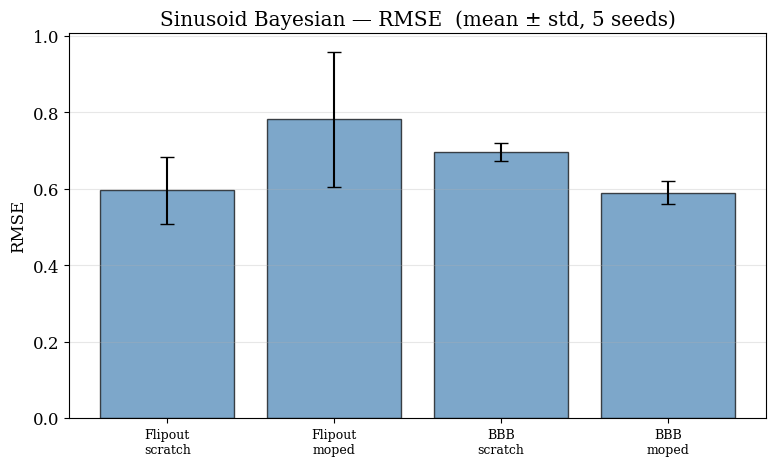

Saved: 5seed_sinusoid_bayesian_rmse_bar.png


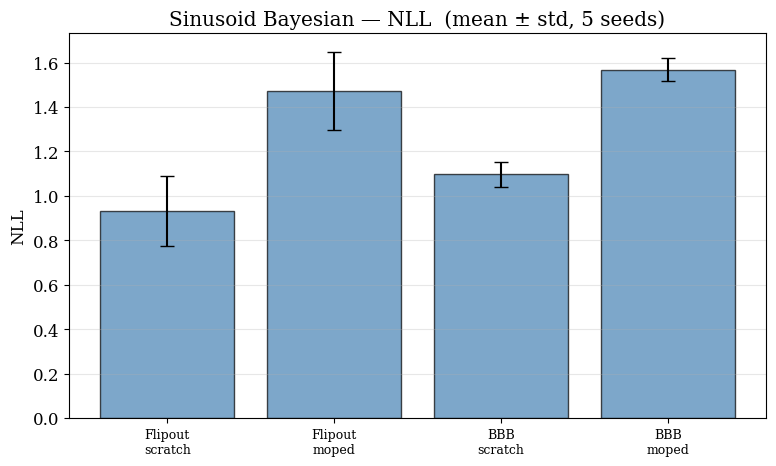

Saved: 5seed_sinusoid_bayesian_nll_bar.png


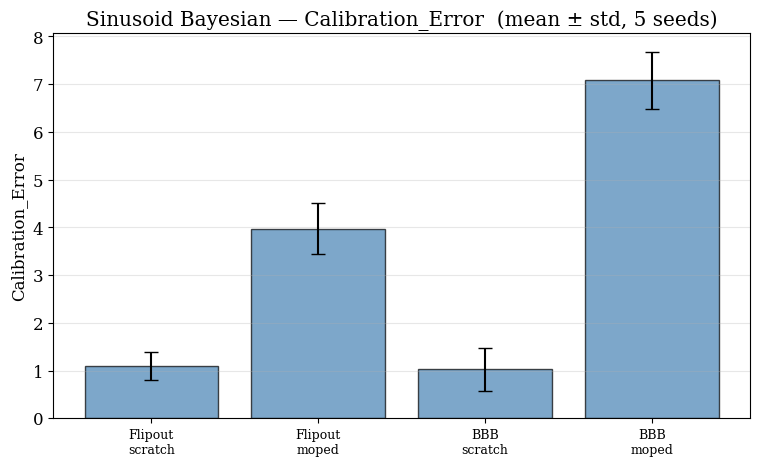

Saved: 5seed_sinusoid_bayesian_calibration_error_bar.png


In [6]:
plot_metrics = ["RMSE", "NLL", "Calibration_Error"]
titles = [s["plot_title"].replace(" / ", "/") for s in variant_specs]
n = len(titles)
x = np.arange(n)

for mk in plot_metrics:
    means = [agg[s["variant_name"]][f"{mk}_mean"] for s in variant_specs]
    stds  = [agg[s["variant_name"]][f"{mk}_std"]  for s in variant_specs]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x, means, yerr=stds, capsize=5, color="steelblue", alpha=0.7, edgecolor="k")
    ax.set_xticks(x)
    ax.set_xticklabels(titles, fontsize=12, rotation=30, ha="right")
    ax.set_ylabel(mk)
    ax.set_title(f"Sinusoid Bayesian: {mk}  (mean \u00b1 std, {len(SEEDS)} seeds)")
    ax.grid(True, alpha=0.3, axis="y")
    fname = f"5seed_sinusoid_bayesian_{mk.lower()}_bar.png"
    fig.savefig(os.path.join(FIGURES_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


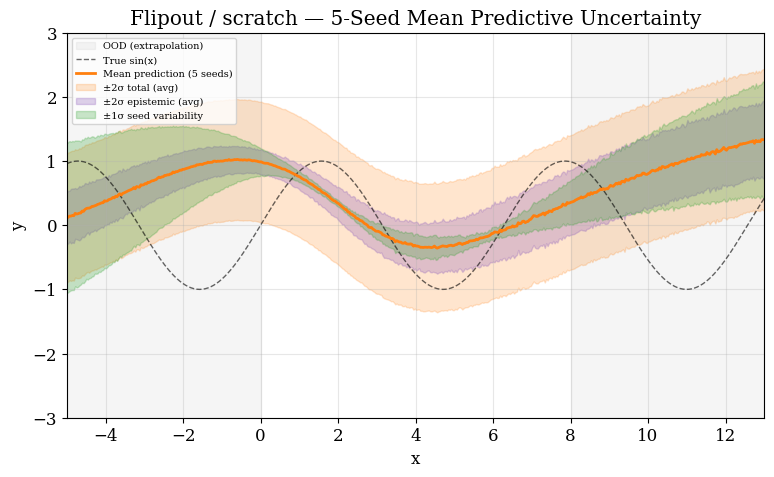

  Saved: 5seed_sinusoid_flipout_scratch_prediction.png


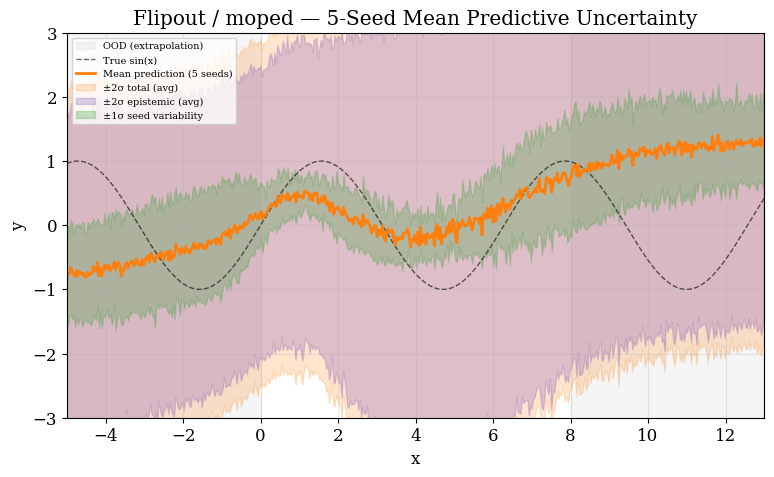

  Saved: 5seed_sinusoid_flipout_moped_prediction.png


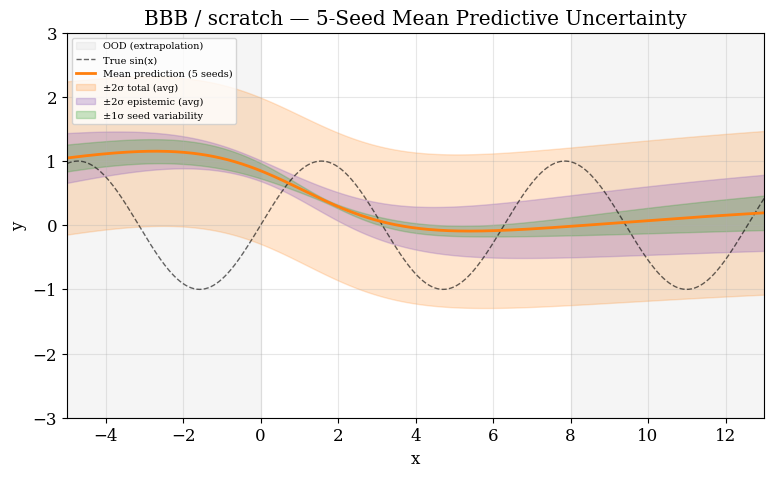

  Saved: 5seed_sinusoid_bbb_scratch_prediction.png


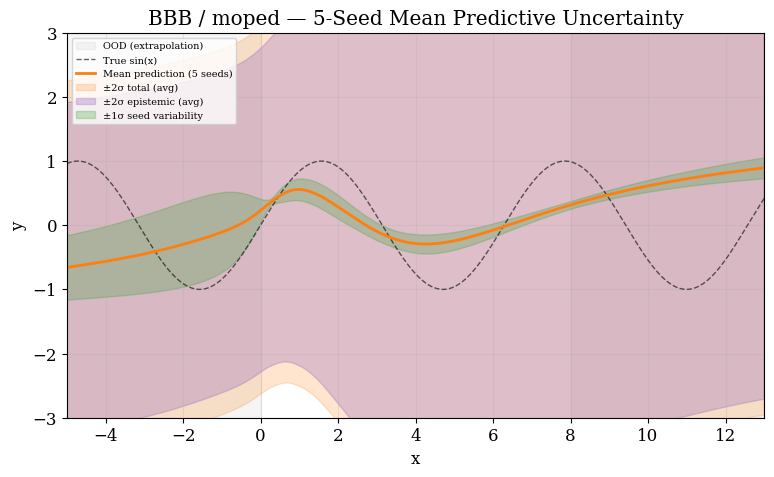

  Saved: 5seed_sinusoid_bbb_moped_prediction.png

Done: 4 prediction figures


In [7]:
plot_regression_prediction_bands(
    variant_specs, all_seed_preds, SEEDS, x_grid, TRAIN_LO, TRAIN_HI,
    FIGURES_DIR, "5seed_sinusoid")

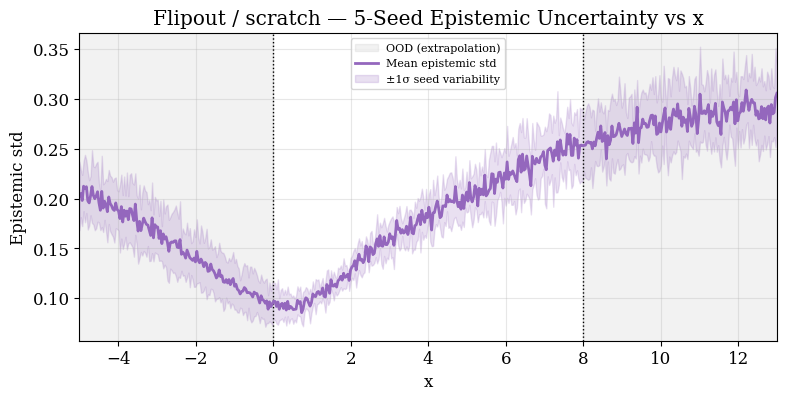

  Saved: 5seed_sinusoid_flipout_scratch_ood_epistemic.png


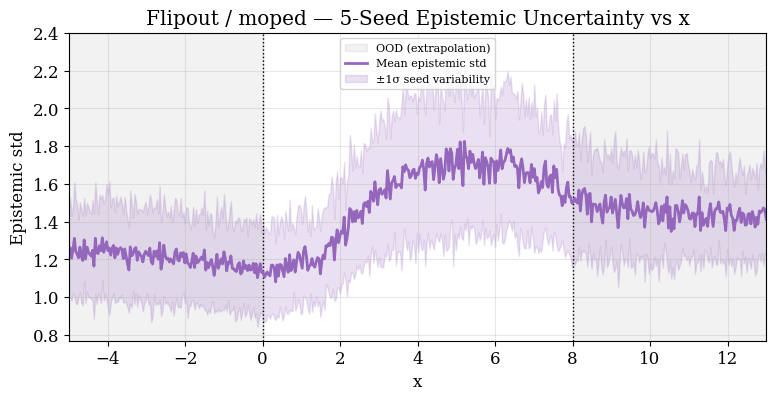

  Saved: 5seed_sinusoid_flipout_moped_ood_epistemic.png


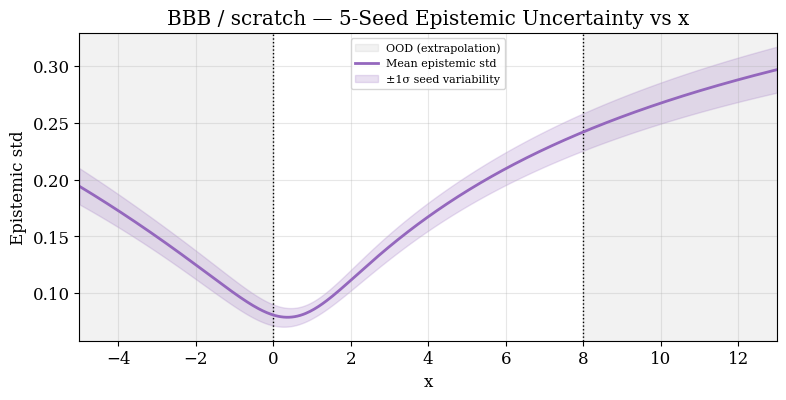

  Saved: 5seed_sinusoid_bbb_scratch_ood_epistemic.png


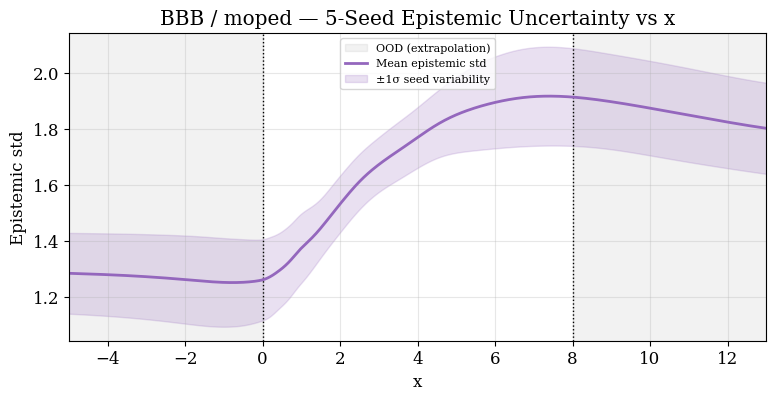

  Saved: 5seed_sinusoid_bbb_moped_ood_epistemic.png

Done: 4 OOD epistemic figures


In [8]:
plot_regression_ood_epistemic(
    variant_specs, all_seed_preds, SEEDS, x_grid, TRAIN_LO, TRAIN_HI,
    FIGURES_DIR, "5seed_sinusoid")

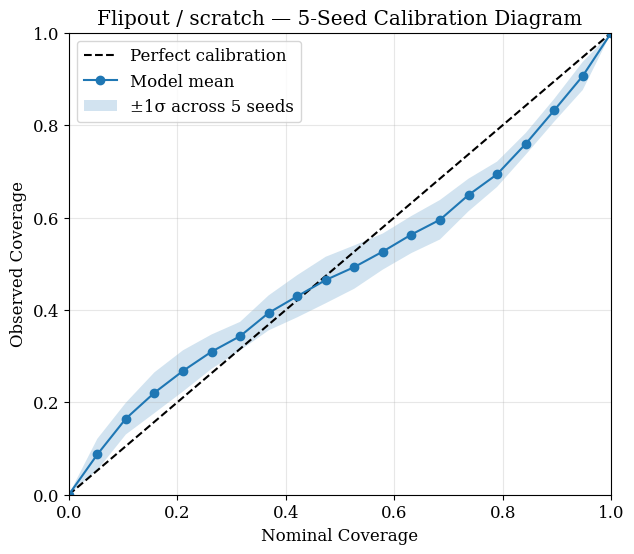

  Saved: 5seed_sinusoid_flipout_scratch_calibration.png


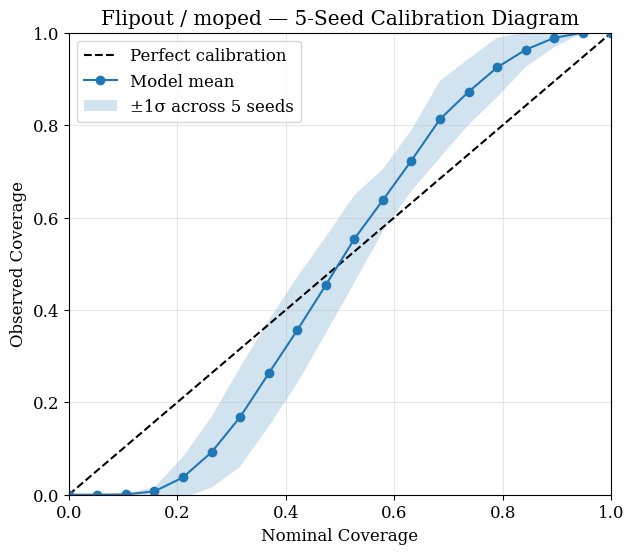

  Saved: 5seed_sinusoid_flipout_moped_calibration.png


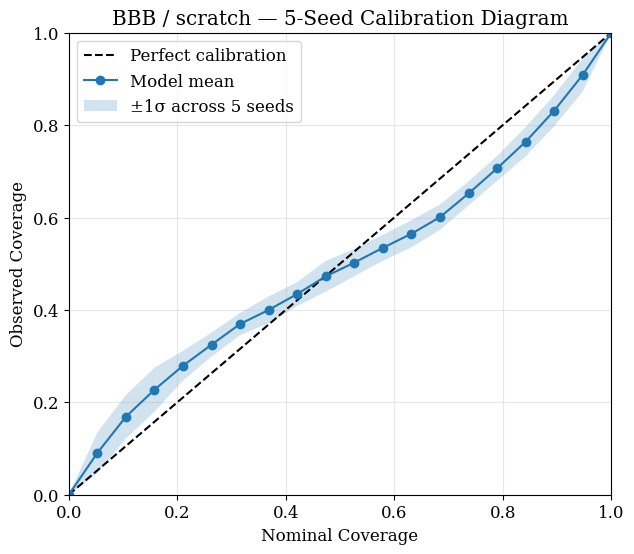

  Saved: 5seed_sinusoid_bbb_scratch_calibration.png


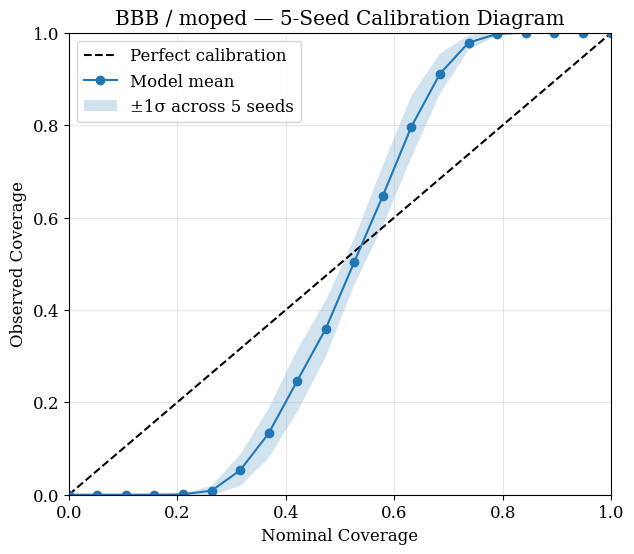

  Saved: 5seed_sinusoid_bbb_moped_calibration.png

Done: 4 calibration figures


In [9]:
# Per-variant calibration curves: mean ± std across seeds
levels = np.linspace(0.0, 1.0, 20)
seed_calibration = {seed: {} for seed in SEEDS}

for seed in SEEDS:
    X_test_id_s, y_test_id_s = all_seed_test_data[seed]

    for spec in variant_specs:
        vname = spec["variant_name"]
        net = all_seed_nets.get(seed, {}).get(vname)
        if net is None:
            print(f"  Warning: {vname} seed {seed} not in memory"); continue
        mu_id, epi_id = bt_predict(net, X_test_id_s, n_samples=num_mc_samples, seed=seed)
        sigma_bt = all_seed_sigma.get(seed, {}).get(vname, sigma_noise)
        total_id = combine_predictive_std(epi_id, sigma_bt)
        _, observed = regression_calibration_curve(y_test_id_s, mu_id, total_id, n_levels=20)
        seed_calibration[seed][vname] = observed

plot_regression_calibration(
    variant_specs, seed_calibration, levels, SEEDS, FIGURES_DIR, "5seed_sinusoid")